# Cancer Cohort Extraction and Validation from Synthetic EHR Data

## Objective

The goal of this analysis is to identify and validate a cancer patient cohort from synthetic EHR data generated using Synthea. The workflow demonstrates a reproducible healthcare analytics pipeline including:

1. Raw EHR data overview
2. Data cleaning and preprocessing
3. Cancer cohort extraction using diagnosis codes and descriptions
4. Cohort validation and sanity checks
5. Exploratory analysis and visualization
6. Summary and limitations


# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIG_DIR = Path("../figures")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_DATE = pd.Timestamp("2022-11-12") # date the dataset was published


# 2. Load EHR Tables

This analysis primarily uses:

- `conditions.csv` → diagnosis information
- `patients.csv` → demographics
- `encounters.csv` → healthcare utilization
- `medications.csv`, `procedures.csv`, `observations.csv` → used for cohort validation

In [2]:
patients = pd.read_csv(RAW_DIR / "patients.csv")
conditions = pd.read_csv(RAW_DIR / "conditions.csv")
encounters = pd.read_csv(RAW_DIR / "encounters.csv")
medications = pd.read_csv(RAW_DIR / "medications.csv")
procedures = pd.read_csv(RAW_DIR / "procedures.csv")
observations = pd.read_csv(RAW_DIR / "observations.csv")

print("Patients:", patients.shape)
print("Conditions:", conditions.shape)
print("Encounters:", encounters.shape)
print("Medications:", medications.shape)
print("Procedures:", procedures.shape)
print("Observations:", observations.shape)


Patients: (15354, 25)
Conditions: (866514, 6)
Encounters: (1371435, 15)
Medications: (1589918, 13)
Procedures: (2425255, 9)
Observations: (11161255, 9)


# 3. Raw Data Overview

In [3]:
conditions.head()

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION
0,1988-04-02,NaN,5605b66b-e92d-c16c-1b83-b8bf7040d51f,be3e07a4-00ea-4e1f-6e5c-32620712d7e1,162864005,Body mass index 30+ - obesity (finding)
1,1954-08-27,NaN,c06a2ab3-c3b1-a3d0-7c12-262a12c6885e,3e2dd16e-a2f0-6467-1950-84ef2e834c73,224295006,Only received primary school education (finding)
2,1954-08-27,1955-09-02,c06a2ab3-c3b1-a3d0-7c12-262a12c6885e,3e2dd16e-a2f0-6467-1950-84ef2e834c73,160903007,Full-time employment (finding)
3,1954-08-27,1958-09-05,c06a2ab3-c3b1-a3d0-7c12-262a12c6885e,3e2dd16e-a2f0-6467-1950-84ef2e834c73,422650009,Social isolation (finding)
4,1955-09-02,1958-09-05,c06a2ab3-c3b1-a3d0-7c12-262a12c6885e,2f572a12-0189-7eba-f11c-d308deb08435,160903007,Full-time employment (finding)


In [4]:
patients.head()

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
0,5605b66b-e92d-c16c-1b83-b8bf7040d51f,1977-03-19,NaN,999-94-9633,S99930485,X51431379X,Mrs.,Nikita578,Erdman779,NaN,Leannon79,M,white,nonhispanic,F,Wakefield Massachusetts US,510 Little Station Unit 69,Quincy,Massachusetts,Norfolk County,2186.0,42.290937,-70.975503,1.382106e+06,390849.2625
1,c06a2ab3-c3b1-a3d0-7c12-262a12c6885e,1936-07-03,NaN,999-76-5032,S99927160,X37795263X,Mr.,Miguel Ángel46,Atencio773,NaN,NaN,M,white,hispanic,M,San Jose San Jose CR,1022 Hermann Quay Suite 79,Springfield,Massachusetts,Hampden County,1118.0,42.119725,-72.529805,2.118565e+06,108146.8010
2,6e5ae27c-8038-7988-e2c0-25a103f01bfa,1940-02-19,NaN,999-83-7940,S99932661,X36822066X,Mr.,Zane918,Hodkiewicz467,NaN,NaN,M,white,nonhispanic,M,Brookline Massachusetts US,747 Conn Throughway,Boston,Massachusetts,Suffolk County,2135.0,42.308831,-71.063162,2.007909e+06,333884.4150
3,94d39619-8e17-d248-41b3-9ec1f2d031b2,1954-11-08,2010-01-10,999-84-3708,S99923522,X49705907X,Mr.,Emmett200,Collins926,NaN,NaN,M,white,nonhispanic,M,Baldwinville Massachusetts US,675 Ortiz Mission Unit 59,Hingham,Massachusetts,Plymouth County,2043.0,42.257452,-70.848673,2.637311e+06,149574.3525
4,23832f5d-e045-2541-1626-a65dce9bbcf7,1972-04-13,NaN,999-89-5858,S99939931,X88479701X,Mrs.,Magan944,Green467,NaN,Morar593,M,white,nonhispanic,F,Worcester Massachusetts US,427 Jakubowski Viaduct Unit 76,Edgartown,Massachusetts,Dukes County,NaN,41.364910,-70.519177,1.859584e+06,69524.1780


#### Missing Values

##### patients

In [5]:
patients.isnull().sum().sort_values(ascending=False).head(10)

SUFFIX       15092
DEATHDATE    10000
MAIDEN        9730
ZIP           6958
MARITAL        376
PASSPORT       289
PREFIX         267
DRIVERS        234
Id               0
ADDRESS          0
dtype: int64

##### conditions

In [6]:
# Missing value overview
conditions.isnull().sum().sort_values(ascending=False).head(10)


STOP           160918
START               0
PATIENT             0
ENCOUNTER           0
CODE                0
DESCRIPTION         0
dtype: int64

Most import analytical variables demonstrated minimal missingness.

# 4. Data Cleaning and Standardization

Key preprocessing steps:
- Remove duplicate rows
- Standardize diagnosis descriptions
- Convert dates
- Remove invalid records


In [7]:
# Remove duplicates
conditions = conditions.drop_duplicates()
patients = patients.drop_duplicates()
encounters = encounters.drop_duplicates()
medications = medications.drop_duplicates()
observations = observations.drop_duplicates()
procedures = procedures.drop_duplicates()

# Convert dates
for df in [conditions, encounters, medications, procedures]:
    for col in ["START", "STOP"]:
        if col in df.columns:
            df[col] = pd.to_datetime(
                df[col],
                errors="coerce"
            )

for col in ["BIRTHDATE", "DEATHDATE"]:
    if col in patients.columns:
        patients[col] = pd.to_datetime(
            patients[col],
            errors="coerce"
        )

# Standardize diagnosis descriptions
conditions['DESCRIPTION_CLEAN'] = (
    conditions['DESCRIPTION']
    .astype(str)
    .str.lower()
    .str.strip()
)

print("Conditions after cleaning:", conditions.shape)


Conditions after cleaning: (866514, 7)


# 5. Cancer Cohort Definition

## Strategy

This analysis uses BOTH:
1. Structured diagnosis codes (`CODE`)
2. Diagnosis descriptions (`DESCRIPTION`)

Using both approaches improves robustness and reflects real-world EHR analytics workflows.

## Inclusion Criteria

Patients with diagnosis descriptions containing:
- malignant
- carcinoma
- cancer
- leukemia
- lymphoma
- melanoma
- neoplasm

## Exclusion Criteria

Exclude:
- family history of cancer
- screening encounters
- benign tumors
- rule out diagnoses



## Structured Code-Based Cancer Cohort Extraction

Synthea primarily uses SNOMED CT diagnosis codes rather than ICD10 codes.

To improve reproducibility and reduce false positives, cancer patients are first identified using structured diagnosis codes associated with malignant neoplastic diseases.

Diagnosis descriptions are then used as a secondary validation and supplemental identification strategy.


In [8]:
cancer_codes = [
    # General malignant neoplasm
    363346000,   # malignant neoplastic disease
    55342001,    # neoplastic disease
    399981008,   # neoplasm and/or hamartoma
    108369006,   # neoplasm of uncertain behavior
    126906006,   # neoplasm of body structure
    # Lung cancer
    254637007,   # non-small cell lung cancer
    254632001,   # small cell carcinoma of lung
    162573006,   # malignant tumor of lung
    # Breast cancer
    254837009,   # malignant neoplasm of breast
    93796005,    # primary malignant neoplasm of breast
    # Colorectal cancer
    93761005,    # primary malignant neoplasm of colon
    363406005,   # malignant tumor of colon
    363510005,   # malignant tumor of rectum
    109838007,   # colorectal cancer
    # Prostate cancer
    314994000,   # metastatic malignant neoplasm to prostate
    126906006,   # neoplasm of prostate
    # Skin cancer / melanoma
    372244006,   # malignant melanoma of skin
    93655004,    # malignant melanoma
    # Leukemia
    93143009,    # leukemia
    91857003,    # acute leukemia
    92814006,    # chronic leukemia
    # Lymphoma
    118601006,   # lymphoma
    109979007,   # non-Hodgkin lymphoma
    93143009,    # Hodgkin disease
    # Brain / CNS
    254956000,   # malignant neoplasm of brain
    # Liver
    93880001,    # primary malignant neoplasm of liver
    # Pancreatic cancer
    372003004,   # malignant tumor of pancreas
    # Kidney cancer
    254915003,   # malignant tumor of kidney
    # Bladder cancer
    399326009,   # malignant tumor of urinary bladder
    # Ovarian cancer
    363443007,   # malignant tumor of ovary
    # Cervical cancer
    363354003,   # malignant tumor of cervix
    # Uterine cancer
    363367002,   # malignant neoplasm of uterus
    # Thyroid cancer
    363478007,   # malignant tumor of thyroid gland
    # Gastric cancer
    363349002,   # malignant tumor of stomach
    # Esophageal cancer
    254634000,   # malignant tumor of esophagus
    # Metastatic disease
    128462008,   # secondary malignant neoplasm
    94503003,    # metastatic malignant neoplasm
]

conditions['CODE_STR'] = conditions['CODE'].astype(str)

cancer_code_set = set([str(code) for code in cancer_codes])

# Structured-code cohort extraction
code_based_conditions = conditions[conditions['CODE_STR'].isin(cancer_code_set)].copy()

print("Structured-code cancer condition rows:", code_based_conditions.shape[0])

print("Unique structured-code cancer patients:", code_based_conditions['PATIENT'].nunique())


Structured-code cancer condition rows: 3593
Unique structured-code cancer patients: 2484


## Diagnosis Descriptions-Based Cancer Cohort Extraction
Patients with cancer were identified using diagnosis terminology from the CONDITIONS table.
The selected terms were chosen to capture a broad range of common oncology-related terminology used in diagnosis descriptions.

For example:
- `cancer` and `malignant` capture general malignancy terminology
- `carcinoma` and `neoplasm` capture common solid tumor descriptions
- `leukemia` and `lymphoma` capture hematologic malignancies
- `melanoma` captures common skin malignancies

Using multiple related terms improves sensitivity and reduces the likelihood of missing cancer-related diagnoses that may not explicitly contain the word “cancer.”

This represents an initial rule-based phenotype definition using malignant neoplasm-related terminology.

In [9]:
# Cancer inclusion terms
cancer_terms = [
    r'malignant',
    r'carcinoma',
    r'cancer',
    r'leukemia',
    r'lymphoma',
    r'melanoma',
    r'neoplasm'
]

# Exclusion terms
exclude_terms = [
    r'family history',
    r'screening',
    r'history of',
    r'at risk',
    r'suspected',
    r'suspicious',
    r'possible',
    r'rule out',
    r'\(situation\)'
]

include_pattern = '|'.join(cancer_terms)
exclude_pattern = '|'.join(exclude_terms)

include_mask = conditions['DESCRIPTION_CLEAN'].str.contains(
    include_pattern,
    regex=True,
    na=False
)

exclude_mask = conditions['DESCRIPTION_CLEAN'].str.contains(
    exclude_pattern,
    regex=True,
    na=False
)

cancer_conditions = conditions[include_mask & ~exclude_mask].copy()

print("Cancer-related condition rows:", cancer_conditions.shape[0])
print("Unique cancer patients:", cancer_conditions['PATIENT'].nunique())


Cancer-related condition rows: 4803
Unique cancer patients: 2533


## Combine cohort

In [10]:
# Combine structured-code and text-based cohort extraction

combined_cancer_conditions = pd.concat([
    code_based_conditions,
    cancer_conditions
]).drop_duplicates()

combined_cancer_conditions = combined_cancer_conditions[
    ~combined_cancer_conditions['DESCRIPTION_CLEAN'].str.contains(
        exclude_pattern,
        regex=True,
        na=False
    )
]

print("Combined cancer-related condition rows:", combined_cancer_conditions.shape[0])
print("Unique cancer patients:", combined_cancer_conditions['PATIENT'].nunique())

Combined cancer-related condition rows: 4803
Unique cancer patients: 2533


### Final Cohort Comparison

In [11]:
# Patients from each method
text_patients = set(cancer_conditions['PATIENT'].unique())
code_patients = set(code_based_conditions['PATIENT'].unique())
combined_patients = set(combined_cancer_conditions['PATIENT'].unique())
# Overlap analysis
overlap_patients = text_patients & code_patients
text_only_patients = text_patients - code_patients
code_only_patients = code_patients - text_patients

In [12]:
overlap_table = pd.DataFrame({
    'Cohort Type': [
        'Structured codes',
        'Text matching',
        'Overlap',
        'Text-only',
        'Code-only',
        'Combined unique'
    ],
    'Patient Count': [
        len(code_patients),
        len(text_patients),
        len(overlap_patients),
        len(text_only_patients),
        len(code_only_patients),
        len(combined_patients)
    ]
})

overlap_table

,Cohort Type,Patient Count
0,Structured codes,2484
1,Text matching,2533
2,Overlap,2484
3,Text-only,49
4,Code-only,0
5,Combined unique,2533


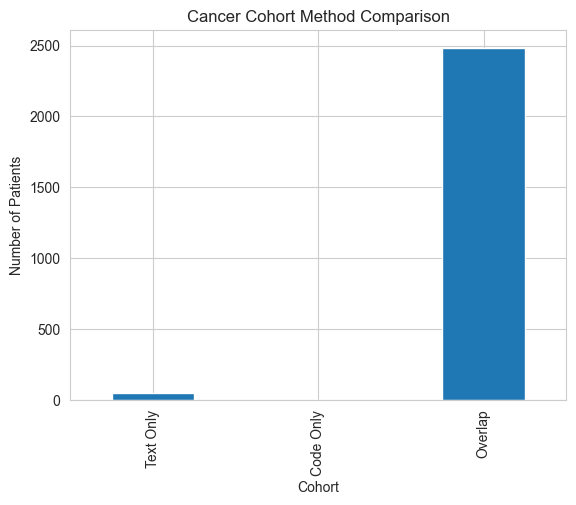

In [13]:
comparison_df = pd.DataFrame({
    'Cohort': ['Text Only', 'Code Only', 'Overlap'],
    'Patients': [
        len(text_only_patients),
        len(code_only_patients),
        len(overlap_patients)
    ]
})

comparison_df.plot(
    kind='bar',
    x='Cohort',
    y='Patients',
    legend=False
)

plt.ylabel("Number of Patients")
plt.title("Cancer Cohort Method Comparison")
plt.savefig(FIG_DIR / "Cancer_Cohort_Method_Comparison.png")
plt.show()

Since the code-based cohort is a subset of the text-based cohort, we will use `cancer_conditions` and `combined_cancer_conditions` interchangeably in the following sections.

#### Review the text only cohort

In [14]:
text_only_conditions = cancer_conditions[
    cancer_conditions['PATIENT'].isin(text_only_patients)
]

(
    text_only_conditions['DESCRIPTION']
    .value_counts()
    .head(30)
)

DESCRIPTION
Secondary malignant neoplasm of colon    49
Name: count, dtype: int64

Only one condition in the text only condition: `Secondary malignant neoplasm of colon`. Check the code that was missed in the code-based method

In [15]:
conditions[conditions['DESCRIPTION']== 'Secondary malignant neoplasm of colon'][['CODE', 'DESCRIPTION']].drop_duplicates()

,CODE,DESCRIPTION
21050,94260004,Secondary malignant neoplasm of colon


# 6. Review Cancer Diagnosis Descriptions

In [16]:
combined_cancer_conditions['DESCRIPTION'].value_counts().head(20)

DESCRIPTION
Neoplasm of prostate                                                     1268
Carcinoma in situ of prostate (disorder)                                 1159
Malignant neoplasm of breast (disorder)                                   512
Non-small cell lung cancer (disorder)                                     450
Non-small cell carcinoma of lung  TNM stage 1 (disorder)                  450
Overlapping malignant neoplasm of colon                                   260
Malignant tumor of colon                                                  200
Metastasis from malignant tumor of prostate (disorder)                    191
Small cell carcinoma of lung (disorder)                                    89
Primary small cell malignant neoplasm of lung  TNM stage 1 (disorder)      89
Primary malignant neoplasm of colon                                        83
Secondary malignant neoplasm of colon                                      52
Name: count, dtype: int64

# 7. Create Patient-Level Cancer Cohort

In [17]:
first_cancer_dx = (
    combined_cancer_conditions
    .groupby("PATIENT")["START"]
    .min()
    .reset_index()
    .rename(columns={"START":"FIRST_CANCER_DATE"})
)

cohort = first_cancer_dx.merge(
    patients,
    left_on="PATIENT",
    right_on="Id",
    how="left"
)

cohort.head()


,PATIENT,FIRST_CANCER_DATE,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
0,000eba84-0d5c-2657-0b5e-0c70f2f746c2,1989-06-03,000eba84-0d5c-2657-0b5e-0c70f2f746c2,1929-04-06,NaT,999-18-7950,S99957211,X41011359X,Mr.,Boyce638,Johns824,NaN,NaN,M,white,nonhispanic,M,West Springfield Massachusetts US,902 Dibbert Common Apt 67,Dighton,Massachusetts,Bristol County,NaN,41.798910,-71.196704,3.008311e+06,297474.4500
1,001209d3-9cd3-a700-69ea-c9982213efea,1989-02-04,001209d3-9cd3-a700-69ea-c9982213efea,1926-11-27,1992-10-22,999-74-9899,S99912221,X44113995X,Mr.,Michale231,Macejkovic424,NaN,NaN,M,black,nonhispanic,M,Sharon Massachusetts US,295 Wintheiser Throughway Suite 65,Swampscott,Massachusetts,Essex County,NaN,42.463916,-70.879934,1.670533e+06,191566.0775
2,00553b46-47fb-e90c-ce55-c26b8ddc6de9,2009-04-01,00553b46-47fb-e90c-ce55-c26b8ddc6de9,1932-08-23,NaT,999-99-2906,S99952781,X61422441X,Mr.,Graham902,Senger904,NaN,NaN,M,white,nonhispanic,M,Quincy Massachusetts US,193 Bosco Rapid Suite 19,Fitchburg,Massachusetts,Worcester County,NaN,42.582840,-71.860661,1.314520e+07,151838.7775
3,005ca8f0-e643-f614-fd0a-3872463aaacc,2014-01-24,005ca8f0-e643-f614-fd0a-3872463aaacc,1945-09-18,NaT,999-37-2166,S99998188,X20204168X,Mrs.,Juliette736,Jacobson885,MD,Ledner144,M,white,nonhispanic,F,Cambridge Massachusetts US,207 Lesch Crossing,Boston,Massachusetts,Suffolk County,2134.0,42.295264,-71.102500,1.322756e+06,137638.8785
4,00626e2c-3fbf-3ee4-1f32-ea31daa4e72f,2011-11-16,00626e2c-3fbf-3ee4-1f32-ea31daa4e72f,1930-10-12,2014-02-22,999-28-9417,S99926467,X3694689X,Ms.,Milda157,Haley279,NaN,NaN,S,white,nonhispanic,F,East Harwich Massachusetts US,700 Donnelly Trace,Brookline,Massachusetts,Norfolk County,2446.0,42.279035,-71.159588,2.950068e+06,350315.1595


In [18]:
cohort["AGE_AT_DIAGNOSIS"] = (
    cohort["FIRST_CANCER_DATE"] -
    cohort["BIRTHDATE"]
).dt.days / 365.25

cohort["AGE_AT_DIAGNOSIS"].describe()

count    2533.000000
mean       63.350716
std        11.063446
min         2.088980
25%        60.158795
50%        63.917864
75%        69.440110
max        97.952088
Name: AGE_AT_DIAGNOSIS, dtype: float64

# 8. Cancer Cohort Demographics

### Age distribution 

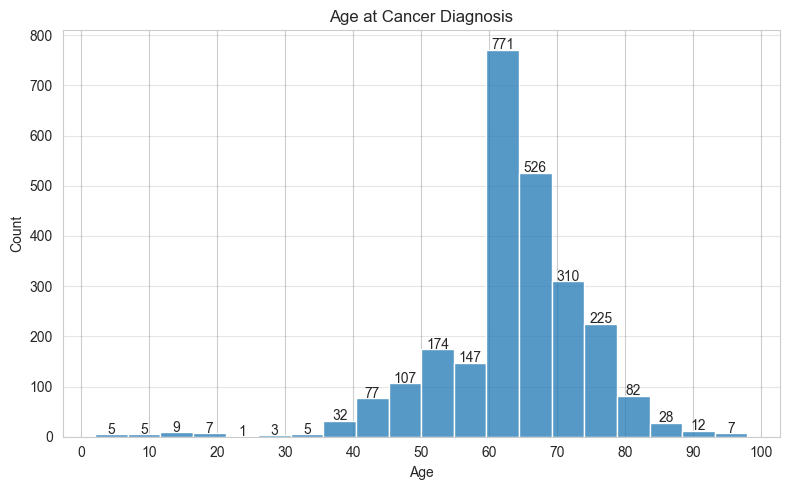

In [19]:
plt.figure(figsize=(8,5))

ax = sns.histplot(
    cohort["AGE_AT_DIAGNOSIS"],
    bins=20
)

# Add count labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        plt.text(
            p.get_x() + p.get_width()/2,
            height + 1,
            int(height),
            ha='center'
        )

# X-axis ticks every 10 years
plt.xticks(range(0, int(cohort["AGE_AT_DIAGNOSIS"].max()) + 10, 10))
plt.grid(axis='y', color='gray', alpha=0.2)
plt.title("Age at Cancer Diagnosis")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "age_at_diagnosis.png")
plt.show()


### Cohort gender distribution

In [20]:
# Gender summary table
cohort_gender_summary = (
    cohort["GENDER"]
    .value_counts()
    .reset_index()
)

cohort_gender_summary.columns = [
    "GENDER",
    "PATIENT_COUNT"
]

cohort_gender_summary

,GENDER,PATIENT_COUNT
0,M,1773
1,F,760


### Cohort race distribution

In [21]:
cohort_race_summary = (
    cohort["RACE"]
    .value_counts()
    .reset_index()
)
cohort_race_summary.columns = [
    "RACE",
    "PATIENT_COUNT"
]
cohort_race_summary

,RACE,PATIENT_COUNT
0,white,2119
1,black,189
2,asian,183
3,hawaiian,22
4,other,12
5,native,8


### Cohort enthnicity distribution

In [22]:
cohort_ethnicity_summary = (
    cohort["ETHNICITY"]
    .value_counts()
    .reset_index()
)

cohort_ethnicity_summary.columns = [
    "ETHNICITY",
    "PATIENT_COUNT"
]

cohort_ethnicity_summary

,ETHNICITY,PATIENT_COUNT
0,nonhispanic,2263
1,hispanic,270


### Smoking status
Smoking status was explored as an additional cohort characterization variable due to its clinical relevance in oncology and population health studies.

Observation-level data was otherwise largely composed of general vitals and survey measurements rather than oncology-specific indicators.

In [23]:
# Smoking status characterization
smoking_obs = observations[
    observations["DESCRIPTION"] ==
    "Tobacco smoking status NHIS"
].copy()

smoking_status = (
    smoking_obs[
        ["PATIENT", "VALUE"]
    ]
    .drop_duplicates()
)

cohort_smoking = cohort.merge(
    smoking_status,
    left_on="PATIENT",
    right_on="PATIENT",
    how="left"
)

smoking_summary = (
    cohort_smoking["VALUE"]
    .value_counts()
    .reset_index()
)

smoking_summary.columns = [
    "SMOKING_STATUS",
    "PATIENT_COUNT"
]

smoking_summary

,SMOKING_STATUS,PATIENT_COUNT
0,Never smoker,1414
1,Former smoker,1116
2,Current every day smoker,2


# 9. Cancer Type Classification

In [24]:
def classify_cancer(description):
    description = str(description).lower()
    if "breast" in description:
        return "Breast"
    elif "lung" in description:
        return "Lung"
    elif "prostate" in description:
        return "Prostate"
    elif "colon" in description:
        return "Colon"
    elif "leukemia" in description:
        return "Leukemia"
    elif "skin" in description or "melanoma" in description:
        return "Skin"
    else:
        return "Other"


In [25]:
cancer_conditions["CANCER_TYPE"] = (
    cancer_conditions["DESCRIPTION"]
    .apply(classify_cancer)
)
cancer_type_counts = (
    cancer_conditions["CANCER_TYPE"]
    .value_counts()
)
cancer_type_counts

CANCER_TYPE
Prostate    2618
Lung        1078
Colon        595
Breast       512
Name: count, dtype: int64

### Cancer Type Distribution Stratified by Gender

In [26]:
cancer_gender_counts = (
    cancer_conditions
    .merge(
        cohort[["PATIENT", "GENDER"]],
        on="PATIENT",
        how="left"
    )
    .groupby(["CANCER_TYPE", "GENDER"])
    ["PATIENT"]
    .nunique()
    .unstack(fill_value=0)
)
cancer_gender_counts["Total"] = (
    cancer_gender_counts.sum(axis=1)
)

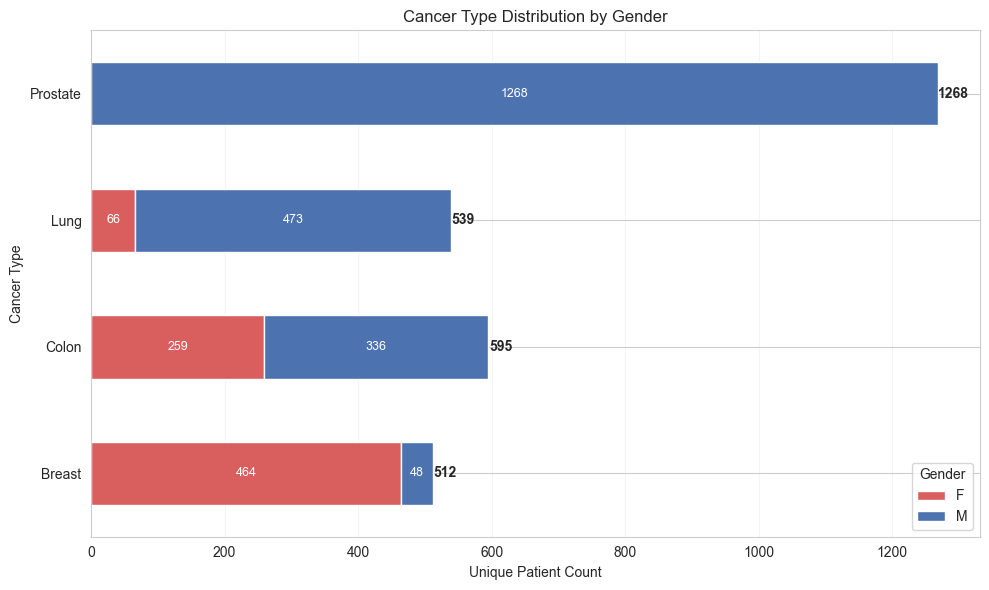

In [27]:
plot_data = cancer_gender_counts.drop(
    columns="Total"
)
ax = plot_data.plot(
    kind="barh",
    stacked=True,
    figsize=(10,6),
    color={
    "F": "#d95f5f",
    "M": "#4c72b0"
    }
)
for i, total in enumerate(
    cancer_gender_counts["Total"]
):
    ax.text(
        total + 1,
        i,
        str(int(total)),
        va="center",
        fontweight="bold"
    )
# Labels inside bar segments
for container in ax.containers:
    labels = [
        f"{int(v)}" if v > 0 else ""
        for v in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9,
        color="white"
    )

plt.title("Cancer Type Distribution by Gender")
plt.xlabel("Unique Patient Count")
plt.ylabel("Cancer Type")
plt.grid(axis="x", alpha=0.2)
plt.legend(title="Gender")
plt.tight_layout()
plt.savefig(FIG_DIR / "cancer_type_distribution_by_gender.png")
plt.show()

# 10. Longitudinal Follow-Up and Healthcare Utilization

In [28]:
encounter_counts = (
    encounters.groupby("PATIENT")
    .size()
    .reset_index(name="ENCOUNTER_COUNT")
)

cohort = cohort.merge(
    encounter_counts,
    on="PATIENT",
    how="left"
)

cohort["ENCOUNTER_COUNT"].describe()


count    2533.000000
mean      155.130280
std       228.158198
min        13.000000
25%        65.000000
50%        93.000000
75%       134.000000
max      2065.000000
Name: ENCOUNTER_COUNT, dtype: float64

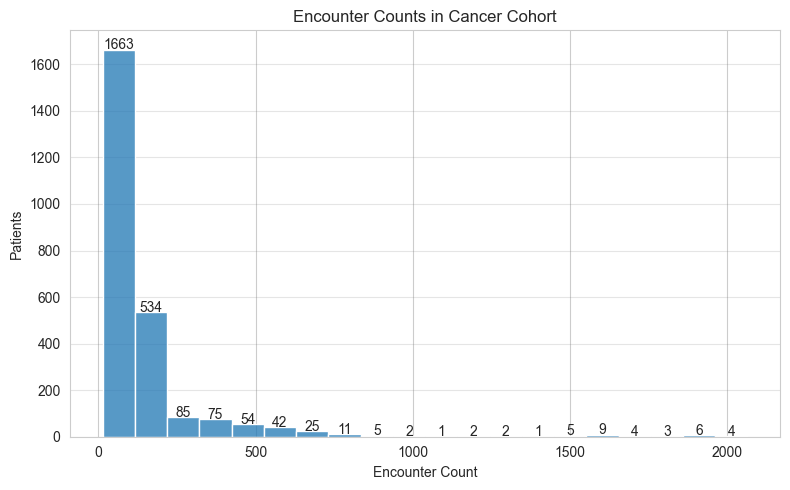

In [29]:
plt.figure(figsize=(8,5))

ax = sns.histplot(
    cohort["ENCOUNTER_COUNT"],
    bins=20
)

# Add count labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        plt.text(
            p.get_x() + p.get_width()/2,
            height + 1,
            int(height),
            ha='center'
        )

plt.grid(axis='y', color='gray', alpha=0.2)

plt.title("Encounter Counts in Cancer Cohort")
plt.xlabel("Encounter Count")
plt.ylabel("Patients")

plt.tight_layout()

plt.savefig(FIG_DIR / "encounter_distribution.png")

plt.show()


### Follow-Up Duration

Follow-up duration was estimated using the interval between first cancer diagnosis and the most recent recorded healthcare encounter.

This provides a longitudinal measure of continued healthcare system engagement after cohort entry.


In [30]:
# Identify last recorded encounter per patient

last_encounter = (
    encounters.groupby("PATIENT")["START"]
    .max()
    .reset_index()
    .rename(columns={"START":"LAST_ENCOUNTER_DATE"})
)

last_encounter.head()


,PATIENT,LAST_ENCOUNTER_DATE
0,0007b281-7eb0-f2b2-d12a-3fc1e2f7e3e2,2001-12-21 15:35:11+00:00
1,0007efd3-c50d-7e51-6a30-8dc08d4269fc,2021-09-07 06:45:29+00:00
2,000eba84-0d5c-2657-0b5e-0c70f2f746c2,2022-01-09 01:41:09+00:00
3,000f23c8-470d-babb-5fda-2b13c6c54e80,2022-01-28 13:01:28+00:00
4,0011c542-8a54-27c3-59d6-1575d265210e,2021-11-11 04:53:25+00:00


In [31]:
# Merge follow-up information into cohort

cohort = cohort.merge(
    last_encounter,
    on="PATIENT",
    how="left"
)

In [32]:
# Calculate follow-up duration in years
# Remove timezone information for datetime consistency

cohort["LAST_ENCOUNTER_DATE"] = (
    cohort["LAST_ENCOUNTER_DATE"]
    .dt.tz_localize(None)
)

cohort["FIRST_CANCER_DATE"] = (
    cohort["FIRST_CANCER_DATE"]
    .dt.tz_localize(None)
) 
cohort["FOLLOWUP_YEARS"] = (

    cohort["LAST_ENCOUNTER_DATE"]
    - cohort["FIRST_CANCER_DATE"]

).dt.days / 365.25

cohort["FOLLOWUP_YEARS"].describe()


count    2533.000000
mean       11.773131
std        11.835288
min         0.000000
25%         3.403149
50%         6.110883
75%        17.839836
max        86.217659
Name: FOLLOWUP_YEARS, dtype: float64

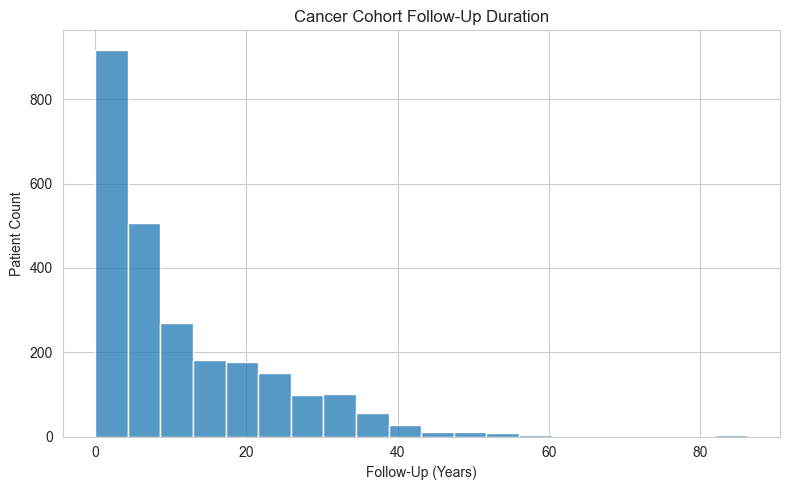

In [33]:
# Visualize follow-up duration
plt.figure(figsize=(8,5))
sns.histplot(
    cohort["FOLLOWUP_YEARS"],
    bins=20
)
plt.title("Cancer Cohort Follow-Up Duration")
plt.xlabel("Follow-Up (Years)")
plt.ylabel("Patient Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "followup_distribution.png")
plt.show()

# 11. Medication-Based Validation

Medication records were explored as an additional validation layer for the diagnosis-based cancer cohort.


In [34]:
medications.head()

,START,STOP,PATIENT,PAYER,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,PAYER_COVERAGE,DISPENSES,TOTALCOST,REASONCODE,REASONDESCRIPTION
0,1995-05-13 22:07:23+00:00,1996-05-18 22:07:23+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,6e2f1a2d-27bd-3701-8d08-dae202c58632,63023e17-bb98-6d93-5296-e1fceb93cbe9,310798,Hydrochlorothiazide 25 MG Oral Tablet,0.00,0.0,12,0.00,59621000.0,Hypertension
1,1995-05-13 22:07:23+00:00,1996-05-18 22:07:23+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,6e2f1a2d-27bd-3701-8d08-dae202c58632,63023e17-bb98-6d93-5296-e1fceb93cbe9,314076,lisinopril 10 MG Oral Tablet,0.01,0.0,371,3.71,59621000.0,Hypertension
2,1996-05-18 22:07:23+00:00,1997-05-24 22:07:23+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,047f6ec3-6215-35eb-9608-f9dda363a44c,9f1a2446-6109-ca43-b3cd-d5f22ba5b433,310798,Hydrochlorothiazide 25 MG Oral Tablet,0.00,0.0,12,0.00,59621000.0,Hypertension
3,1996-05-18 22:07:23+00:00,1997-05-24 22:07:23+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,047f6ec3-6215-35eb-9608-f9dda363a44c,9f1a2446-6109-ca43-b3cd-d5f22ba5b433,314076,lisinopril 10 MG Oral Tablet,0.01,0.0,371,3.71,59621000.0,Hypertension
4,1997-05-24 22:07:23+00:00,1998-05-30 22:07:23+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,c51977a5-225e-a87b-08ec-3280e7c9acca,310798,Hydrochlorothiazide 25 MG Oral Tablet,0.00,0.0,12,0.00,59621000.0,Hypertension


In [35]:
medications["REASONDESCRIPTION"] \
    .value_counts() \
    .head(20)


REASONDESCRIPTION
Hypertension                                                             613347
Diabetes                                                                 250539
Anemia (disorder)                                                         82414
Hyperlipidemia                                                            76217
Childhood asthma                                                          66680
Non-small cell carcinoma of lung  TNM stage 1 (disorder)                  38842
Pulmonary emphysema (disorder)                                            24423
Chronic obstructive bronchitis (disorder)                                 18236
Chronic congestive heart failure (disorder)                               17802
Primary small cell malignant neoplasm of lung  TNM stage 1 (disorder)      9458
Acute bronchitis (disorder)                                                7749
Viral sinusitis (disorder)                                                 3382
Alzheimer's disease (d

In [36]:
medication_validation_terms = [
    "cancer",
    "carcinoma",
    "malignant",
    "neoplasm",
    "leukemia",
    "lymphoma",
    "melanoma"
]
med_pattern = "|".join(medication_validation_terms)
oncology_related_meds = medications[
    medications["REASONDESCRIPTION"]
    .str.contains(
        med_pattern,
        case=False,
        na=False
    )
].copy()
print(
    "Patients with oncology-related medications:",
    oncology_related_meds["PATIENT"].nunique()
)
oncology_related_meds.head()

Patients with oncology-related medications: 1240


,START,STOP,PATIENT,PAYER,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,PAYER_COVERAGE,DISPENSES,TOTALCOST,REASONCODE,REASONDESCRIPTION
303,2005-03-10 04:35:50+00:00,2005-03-10 04:35:50+00:00,94d39619-8e17-d248-41b3-9ec1f2d031b2,6e2f1a2d-27bd-3701-8d08-dae202c58632,2dba409c-6d9b-90d3-c2ed-aeb6e44c3e8e,1736854,Cisplatin 50 MG Injection,213.75,104.06,1,213.75,424132000.0,Non-small cell carcinoma of lung TNM stage 1 ...
304,2005-03-10 04:35:50+00:00,2005-03-10 04:35:50+00:00,94d39619-8e17-d248-41b3-9ec1f2d031b2,6e2f1a2d-27bd-3701-8d08-dae202c58632,2dba409c-6d9b-90d3-c2ed-aeb6e44c3e8e,583214,PACLitaxel 100 MG Injection,3224.08,2361.81,1,3224.08,424132000.0,Non-small cell carcinoma of lung TNM stage 1 ...
305,2005-04-10 02:57:50+00:00,2005-04-10 02:57:50+00:00,94d39619-8e17-d248-41b3-9ec1f2d031b2,6e2f1a2d-27bd-3701-8d08-dae202c58632,a468a706-9964-3a46-f1c4-d525d4c164be,1736854,Cisplatin 50 MG Injection,218.85,107.89,1,218.85,424132000.0,Non-small cell carcinoma of lung TNM stage 1 ...
306,2005-04-10 02:57:50+00:00,2005-04-10 02:57:50+00:00,94d39619-8e17-d248-41b3-9ec1f2d031b2,6e2f1a2d-27bd-3701-8d08-dae202c58632,a468a706-9964-3a46-f1c4-d525d4c164be,583214,PACLitaxel 100 MG Injection,3270.03,2396.27,1,3270.03,424132000.0,Non-small cell carcinoma of lung TNM stage 1 ...
309,2005-05-10 14:29:50+00:00,2005-05-10 14:29:50+00:00,94d39619-8e17-d248-41b3-9ec1f2d031b2,6e2f1a2d-27bd-3701-8d08-dae202c58632,c0499837-50da-8002-e245-f55f443fcc9e,1736854,Cisplatin 50 MG Injection,218.66,107.75,1,218.66,424132000.0,Non-small cell carcinoma of lung TNM stage 1 ...


# 12. Procedure-Based Validation

In [37]:
procedures.head()

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,REASONCODE,REASONDESCRIPTION
0,2012-11-21 08:36:35+00:00,2012-11-21 09:09:12+00:00,c06a2ab3-c3b1-a3d0-7c12-262a12c6885e,cb739cd1-4540-e729-2ef1-fc09075f521c,73761001,Colonoscopy,6133.93,NaN,NaN
1,2012-08-18 22:07:23+00:00,2012-08-18 22:45:32+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,e5e22010-0649-229f-013a-44b804bffb11,710824005,Assessment of health and social care needs (pr...,431.40,NaN,NaN
2,2012-08-18 22:07:23+00:00,2012-08-18 22:22:23+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,e5e22010-0649-229f-013a-44b804bffb11,430193006,Medication Reconciliation (procedure),436.43,NaN,NaN
3,2012-08-18 22:45:32+00:00,2012-08-18 23:26:17+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,e5e22010-0649-229f-013a-44b804bffb11,866148006,Screening for domestic abuse (procedure),431.40,NaN,NaN
4,2012-08-18 23:26:17+00:00,2012-08-18 23:38:08+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,e5e22010-0649-229f-013a-44b804bffb11,171207006,Depression screening (procedure),431.40,NaN,NaN


In [38]:
procedures["DESCRIPTION"].value_counts().head(20)

DESCRIPTION
Hospice care (regime/therapy)                                                           320218
Assessment of health and social care needs (procedure)                                  196569
Depression screening (procedure)                                                        154659
Depression screening using Patient Health Questionnaire Two-Item score (procedure)      153951
Assessment of substance use (procedure)                                                 120315
Physical therapy procedure (regime/therapy)                                             113418
Medication Reconciliation (procedure)                                                    99283
Assessment of anxiety (procedure)                                                        95554
Renal dialysis (procedure)                                                               88484
Assessment using Morse Fall Scale (procedure)                                            78838
Screening for drug abuse (procedure)  

In [39]:
procedure_validation_terms = [
    "biopsy",
    "colonoscopy",
    "mastectomy",
    "resection",
    "radiation",
    "oncology"
]

proc_pattern = "|".join(procedure_validation_terms)
oncology_related_procedures = procedures[
    procedures["DESCRIPTION"]
    .str.contains(
        proc_pattern,
        case=False,
        na=False
    )
].copy()
print("Patients with oncology-related procedures:", oncology_related_procedures["PATIENT"].nunique())
oncology_related_procedures.head()

Patients with oncology-related procedures: 6488


,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,REASONCODE,REASONDESCRIPTION
0,2012-11-21 08:36:35+00:00,2012-11-21 09:09:12+00:00,c06a2ab3-c3b1-a3d0-7c12-262a12c6885e,cb739cd1-4540-e729-2ef1-fc09075f521c,73761001,Colonoscopy,6133.93,NaN,NaN
245,2016-05-30 19:41:42+00:00,2016-05-30 20:20:31+00:00,6e5ae27c-8038-7988-e2c0-25a103f01bfa,3addefcb-083f-a1e6-df4f-a244d3de93e7,73761001,Colonoscopy,16330.87,NaN,NaN
256,2017-08-04 20:20:31+00:00,2017-08-04 20:47:04+00:00,6e5ae27c-8038-7988-e2c0-25a103f01bfa,25cb17dc-b3c3-56ae-5296-e339f087e048,73761001,Colonoscopy,11311.46,NaN,NaN
698,2005-03-10 04:35:50+00:00,2005-03-10 07:27:50+00:00,94d39619-8e17-d248-41b3-9ec1f2d031b2,2dba409c-6d9b-90d3-c2ed-aeb6e44c3e8e,703423002,Combined chemotherapy and radiation therapy (p...,14580.28,424132000.0,Non-small cell carcinoma of lung TNM stage 1 ...
701,2005-04-10 02:57:50+00:00,2005-04-10 05:59:50+00:00,94d39619-8e17-d248-41b3-9ec1f2d031b2,a468a706-9964-3a46-f1c4-d525d4c164be,703423002,Combined chemotherapy and radiation therapy (p...,8467.74,424132000.0,Non-small cell carcinoma of lung TNM stage 1 ...


# 13. Validated Cohort Refinement

The validated cohort represents patients with diagnosis-based cancer evidence together with at least one additional supporting evidence source, such as oncology-related medications or cancer-associated procedures.

In [40]:
med_validated = set(oncology_related_meds["PATIENT"])
proc_validated = set(oncology_related_procedures["PATIENT"])
cohort["MEDICATION_VALIDATED"] = (cohort["PATIENT"].isin(med_validated))
cohort["PROCEDURE_VALIDATED"] = (cohort["PATIENT"].isin(proc_validated))
cohort["VALIDATED_COHORT"] = (cohort["MEDICATION_VALIDATED"]|cohort["PROCEDURE_VALIDATED"])
cohort.head()

,PATIENT,FIRST_CANCER_DATE,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,AGE_AT_DIAGNOSIS,ENCOUNTER_COUNT,LAST_ENCOUNTER_DATE,FOLLOWUP_YEARS,MEDICATION_VALIDATED,PROCEDURE_VALIDATED,VALIDATED_COHORT
0,000eba84-0d5c-2657-0b5e-0c70f2f746c2,1989-06-03,000eba84-0d5c-2657-0b5e-0c70f2f746c2,1929-04-06,NaT,999-18-7950,S99957211,X41011359X,Mr.,Boyce638,Johns824,NaN,NaN,M,white,nonhispanic,M,West Springfield Massachusetts US,902 Dibbert Common Apt 67,Dighton,Massachusetts,Bristol County,NaN,41.798910,-71.196704,3.008311e+06,297474.4500,60.158795,140,2022-01-09 01:41:09,32.602327,False,False,False
1,001209d3-9cd3-a700-69ea-c9982213efea,1989-02-04,001209d3-9cd3-a700-69ea-c9982213efea,1926-11-27,1992-10-22,999-74-9899,S99912221,X44113995X,Mr.,Michale231,Macejkovic424,NaN,NaN,M,black,nonhispanic,M,Sharon Massachusetts US,295 Wintheiser Throughway Suite 65,Swampscott,Massachusetts,Essex County,NaN,42.463916,-70.879934,1.670533e+06,191566.0775,62.190281,48,1992-10-24 23:59:41,3.718001,True,True,True
2,00553b46-47fb-e90c-ce55-c26b8ddc6de9,2009-04-01,00553b46-47fb-e90c-ce55-c26b8ddc6de9,1932-08-23,NaT,999-99-2906,S99952781,X61422441X,Mr.,Graham902,Senger904,NaN,NaN,M,white,nonhispanic,M,Quincy Massachusetts US,193 Bosco Rapid Suite 19,Fitchburg,Massachusetts,Worcester County,NaN,42.582840,-71.860661,1.314520e+07,151838.7775,76.605065,435,2022-01-18 22:39:55,12.799452,False,False,False
3,005ca8f0-e643-f614-fd0a-3872463aaacc,2014-01-24,005ca8f0-e643-f614-fd0a-3872463aaacc,1945-09-18,NaT,999-37-2166,S99998188,X20204168X,Mrs.,Juliette736,Jacobson885,MD,Ledner144,M,white,nonhispanic,F,Cambridge Massachusetts US,207 Lesch Crossing,Boston,Massachusetts,Suffolk County,2134.0,42.295264,-71.102500,1.322756e+06,137638.8785,68.350445,86,2022-01-21 02:13:48,7.991786,True,True,True
4,00626e2c-3fbf-3ee4-1f32-ea31daa4e72f,2011-11-16,00626e2c-3fbf-3ee4-1f32-ea31daa4e72f,1930-10-12,2014-02-22,999-28-9417,S99926467,X3694689X,Ms.,Milda157,Haley279,NaN,NaN,S,white,nonhispanic,F,East Harwich Massachusetts US,700 Donnelly Trace,Brookline,Massachusetts,Norfolk County,2446.0,42.279035,-71.159588,2.950068e+06,350315.1595,81.095140,181,2014-02-24 01:48:27,2.275154,True,True,True


In [41]:
initial_count = len(cohort)
validated_count = (cohort["VALIDATED_COHORT"].sum())
excluded_count = (initial_count - validated_count)
validation_flow = pd.DataFrame({
    "Cohort Stage": [
        "Initial Cohort",
        "Validated Cohort",
        "Excluded After Validation"
    ],
    "Patient Count": [
        initial_count,
        validated_count,
        excluded_count
    ]
})
validation_flow


,Cohort Stage,Patient Count
0,Initial Cohort,2533
1,Validated Cohort,1939
2,Excluded After Validation,594


# 14. Phenotype Confidence Scoring

A simplified evidence-based phenotype confidence framework was developed to demonstrate how multiple validation sources may be combined in healthcare analytics workflows.

In [42]:
cohort["VALIDATION_SCORE"] = (
    1
    + cohort["MEDICATION_VALIDATED"].astype(int)
    + cohort["PROCEDURE_VALIDATED"].astype(int)
)

def classify_confidence(score):
    if score == 1:
        return "Low Confidence"
    elif score == 2:
        return "Moderate Confidence"
    else:
        return "High Confidence"
cohort["PHENOTYPE_CONFIDENCE"] = (
    cohort["VALIDATION_SCORE"]
    .apply(classify_confidence)
)
cohort["PHENOTYPE_CONFIDENCE"].value_counts()

PHENOTYPE_CONFIDENCE
High Confidence        1026
Moderate Confidence     913
Low Confidence          594
Name: count, dtype: int64

# 15. Post-Validation Cohort Comparison

The validated cohort was compared against the initial diagnosis-based cohort to evaluate whether refinement steps altered demographic or healthcare utilization patterns.

These comparisons help assess phenotype plausibility and demonstrate the impact of cohort refinement strategies.


## Age at Diagnosis Comparison

Comparing age distributions before and after validation may help identify whether validated patients demonstrate distinct demographic patterns.


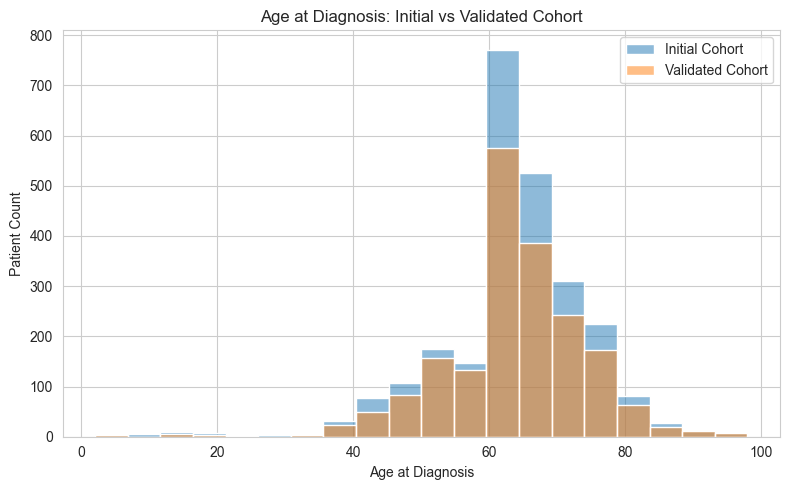

In [43]:
# Create validated subset
validated_subset = cohort[cohort["VALIDATED_COHORT"]].copy()

plt.figure(figsize=(8,5))
sns.histplot(
    cohort["AGE_AT_DIAGNOSIS"],
    bins=20,
    alpha=0.5,
    label="Initial Cohort"
)
sns.histplot(
    validated_subset["AGE_AT_DIAGNOSIS"],
    bins=20,
    alpha=0.5,
    label="Validated Cohort"
)
plt.title("Age at Diagnosis: Initial vs Validated Cohort")
plt.xlabel("Age at Diagnosis")
plt.ylabel("Patient Count")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "validated_age_comparison.png")
plt.show()

# 16. Final Cohort Export

The final exported cohort includes:
- diagnosis-based cohort membership
- validation evidence flags
- phenotype confidence scores
- longitudinal utilization metrics


In [44]:
# Enhanced cohort flow summary

cohort_flow = pd.DataFrame({
    "Cohort Stage": [
        "Total Dataset Population",
        "Initial Cancer Cohort",
        "Medication-Validated Patients",
        "Procedure-Validated Patients",
        "Final Validated Cancer Cohort",
        "Excluded After Validation"
    ],
    "Patient Count": [
        patients.shape[0],
        initial_count,
        cohort["MEDICATION_VALIDATED"].sum(),
        cohort["PROCEDURE_VALIDATED"].sum(),
        validated_count,
        excluded_count   ]
})

cohort_flow["Percent of Initial Cohort"] = (
    cohort_flow["Patient Count"] /
    initial_count * 100
).round(1)

cohort_flow

,Cohort Stage,Patient Count,Percent of Initial Cohort
0,Total Dataset Population,15354,606.2
1,Initial Cancer Cohort,2533,100.0
2,Medication-Validated Patients,1063,42.0
3,Procedure-Validated Patients,1902,75.1
4,Final Validated Cancer Cohort,1939,76.5
5,Excluded After Validation,594,23.5


In [45]:
# Export cohort flow summary
cohort_flow.to_csv(PROCESSED_DIR / "cohort_flow_summary.csv",index=False)
# Export full enriched cohort
cohort.to_csv(PROCESSED_DIR / "full_cancer_cohort.csv",index=False)
# Export validated cohort
validated_cohort = cohort[cohort["VALIDATED_COHORT"]].copy()
validated_cohort.to_csv(PROCESSED_DIR / "validated_cancer_cohort.csv",index=False)
# Export excluded patients
excluded_cohort = cohort[~cohort["VALIDATED_COHORT"]].copy()
excluded_cohort.to_csv(PROCESSED_DIR / "excluded_after_validation.csv",index=False)
# Export phenotype summary
phenotype_summary = (
    cohort["PHENOTYPE_CONFIDENCE"]
    .value_counts()
    .reset_index()
)
phenotype_summary.columns = [
    "PHENOTYPE_CONFIDENCE",
    "PATIENT_COUNT"
]
phenotype_summary.to_csv(PROCESSED_DIR / "phenotype_confidence_summary.csv",index=False)
print("All cohort exports completed successfully.")

All cohort exports completed successfully.


# 17. Sources of Potential Misclassification

## Possible Sources of False Positives
- rule-out diagnoses
- historical cancer diagnoses
- benign neoplasms captured by broad keyword matching
- coding inconsistencies

## Possible Sources of False Negatives
- incomplete encounter history
- under-coded malignancies
- missing structured documentation

A broad diagnosis-based approach generally improves sensitivity but may reduce specificity. More restrictive phenotyping approaches may improve specificity while excluding valid cancer patients.


# 18. Conclusion

This analysis demonstrated:
- longitudinal EHR exploration
- rule-based cohort engineering
- healthcare utilization analysis
- multi-evidence validation workflows
- phenotype confidence scoring
- clinically informed cohort reasoning

# Key Findings

## Cohort Construction
- Cancer cohorts were identified using both diagnosis text matching and SNOMED code matching.
- The code-based cohort was a subset of the text-based cohort, supporting consistency between identification approaches.

## Demographic Characteristics
- The cohort showed variation across gender and age distributions.
- Several cancer types demonstrated noticeable demographic imbalances.

## Smoking Status
- Smoking status information was partially missing for a subset of patients.
- Available smoking data can support exploratory subgroup analyses but should be interpreted cautiously.

## Data Quality & Usability
- Most patient demographic fields were well populated.
- The dataset structure is suitable for downstream statistical modeling and machine learning workflows.


# Limitations

- Diagnosis text may contain ambiguity or inconsistent terminology.
- Some patients may have multiple cancer diagnoses, which can affect cohort grouping.
- Smoking status contains missing values that may bias subgroup analyses.
- Cohort definition assumptions may influence downstream interpretation.
- This analysis is exploratory and intended for data characterization rather than clinical inference.
